# Рубежный контроль №2 (весна 2025 года)
**Студент:** Ларкин Борис Владимирович

**Группа:** ИУ5-61Б

Номер задания - 14

**Задача**  
Для заданного набора данных (по Вашему варианту) постройте модели классификации или регрессии (в зависимости от конкретной задачи, рассматриваемой в наборе данных). Для построения моделей используйте методы 1 и 2 (по варианту для Вашей группы). Оцените качество моделей на основе подходящих метрик качества (не менее двух метрик). Какие метрики качества Вы использовали и почему? Какие выводы Вы можете сделать о качестве построенных моделей? Для построения моделей необходимо выполнить требуемую предобработку данных: заполнение пропусков, кодирование категориальных признаков, и т.д.

**Метод №1**
Линейная/логистическая регрессия

**Метод №2**
Случайный лес

**Датасет**
https://www.kaggle.com/datasets/noriuk/us-education-datasets-unification-project?select=states_all_extended.csv

## Ход работы

Для решения этой задачи я построю модели регрессии, так как целевая переменная (цены на жилье) является непрерывной величиной. Использую два метода: линейную регрессию и случайный лес.

In [243]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
%matplotlib inline

## Загрузка данных

In [244]:
# Загрузка данных
data = pd.read_csv('data/states_all.csv')

## Основные характеристики датасета

In [245]:
# Первые 5 строк датасета
data.head()

,PRIMARY_KEY,STATE,YEAR,ENROLL,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,...,GRADES_4_G,GRADES_8_G,GRADES_12_G,GRADES_1_8_G,GRADES_9_12_G,GRADES_ALL_G,AVG_MATH_4_SCORE,AVG_MATH_8_SCORE,AVG_READING_4_SCORE,AVG_READING_8_SCORE
0,1992_ALABAMA,ALABAMA,1992,NaN,2678885.0,304177.0,1659028.0,715680.0,2653798.0,1481703.0,...,57948.0,58025.0,41167.0,NaN,NaN,731634.0,208.0,252.0,207.0,NaN
1,1992_ALASKA,ALASKA,1992,NaN,1049591.0,106780.0,720711.0,222100.0,972488.0,498362.0,...,9748.0,8789.0,6714.0,NaN,NaN,122487.0,NaN,NaN,NaN,NaN
2,1992_ARIZONA,ARIZONA,1992,NaN,3258079.0,297888.0,1369815.0,1590376.0,3401580.0,1435908.0,...,55433.0,49081.0,37410.0,NaN,NaN,673477.0,215.0,265.0,209.0,NaN
3,1992_ARKANSAS,ARKANSAS,1992,NaN,1711959.0,178571.0,958785.0,574603.0,1743022.0,964323.0,...,34632.0,36011.0,27651.0,NaN,NaN,441490.0,210.0,256.0,211.0,NaN
4,1992_CALIFORNIA,CALIFORNIA,1992,NaN,26260025.0,2072470.0,16546514.0,7641041.0,27138832.0,14358922.0,...,418418.0,363296.0,270675.0,NaN,NaN,5254844.0,208.0,261.0,202.0,NaN


In [246]:
data.shape

(1715, 25)

In [247]:
data.isnull().sum() 

PRIMARY_KEY                        0
STATE                              0
YEAR                               0
ENROLL                           491
TOTAL_REVENUE                    440
FEDERAL_REVENUE                  440
STATE_REVENUE                    440
LOCAL_REVENUE                    440
TOTAL_EXPENDITURE                440
INSTRUCTION_EXPENDITURE          440
SUPPORT_SERVICES_EXPENDITURE     440
OTHER_EXPENDITURE                491
CAPITAL_OUTLAY_EXPENDITURE       440
GRADES_PK_G                      173
GRADES_KG_G                       83
GRADES_4_G                        83
GRADES_8_G                        83
GRADES_12_G                       83
GRADES_1_8_G                     695
GRADES_9_12_G                    644
GRADES_ALL_G                      83
AVG_MATH_4_SCORE                1150
AVG_MATH_8_SCORE                1113
AVG_READING_4_SCORE             1065
AVG_READING_8_SCORE             1153
dtype: int64

In [248]:
from sklearn.impute import SimpleImputer

# Получаем список столбцов с пропущенными значениями
missing_columns = data.columns[data.isnull().any()].tolist()

# Заполняем пропуски средним значением по столбцу
for col in missing_columns:
    # Проверяем, есть ли в столбце непропущенные значения
    if data[col].notna().any():
        # Создаем временный DataFrame для импутации
        temp_data = data[[col]]
        
        # Инициализируем SimpleImputer
        imputer = SimpleImputer(strategy='mean')
        
        # Заполняем пропуски
        imputed_data = imputer.fit_transform(temp_data)
        
        # Возвращаем результат в исходный DataFrame
        data[col] = imputed_data
    else:
        # Если все значения отсутствуют, заполняем нулями
        data[col] = data[col].fillna(0)
        
# Проверяем результат
print(data.isnull().sum())

PRIMARY_KEY                     0
STATE                           0
YEAR                            0
ENROLL                          0
TOTAL_REVENUE                   0
FEDERAL_REVENUE                 0
STATE_REVENUE                   0
LOCAL_REVENUE                   0
TOTAL_EXPENDITURE               0
INSTRUCTION_EXPENDITURE         0
SUPPORT_SERVICES_EXPENDITURE    0
OTHER_EXPENDITURE               0
CAPITAL_OUTLAY_EXPENDITURE      0
GRADES_PK_G                     0
GRADES_KG_G                     0
GRADES_4_G                      0
GRADES_8_G                      0
GRADES_12_G                     0
GRADES_1_8_G                    0
GRADES_9_12_G                   0
GRADES_ALL_G                    0
AVG_MATH_4_SCORE                0
AVG_MATH_8_SCORE                0
AVG_READING_4_SCORE             0
AVG_READING_8_SCORE             0
dtype: int64


Переведем категориальные признаки в численный вид.

In [249]:
def encode_state_feature(data, column='STATE', method='label', drop_original=True, target_column=None):    
    data = data.copy()  # Создаем копию во избежание side effects
    
    if method == 'label':
        encoder = LabelEncoder()
        data[f'{column}_encoded'] = encoder.fit_transform(data[column])
        
    elif method == 'onehot':
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoded = encoder.fit_transform(data[[column]])
        encoded_df = pd.DataFrame(encoded, 
                                 columns=encoder.get_feature_names_out([column]),
                                 index=data.index)
        data = pd.concat([data, encoded_df], axis=1)
        
    elif method == 'ordinal':
        encoder = OrdinalEncoder()
        data[f'{column}_encoded'] = encoder.fit_transform(data[[column]])
        
    elif method == 'frequency':
        freq = data[column].value_counts(normalize=True)
        data[f'{column}_freq'] = data[column].map(freq)
        
    elif method == 'target':
        if target_column is None:
            raise ValueError("Для target encoding нужно задать target_column")
        mean_target = data.groupby(column)[target_column].mean()
        data[f'{column}_target'] = data[column].map(mean_target)
    
    else:
        raise ValueError(f"Неизвестный метод кодирования: {method}. "
                       f"Допустимые значения: 'label', 'onehot', 'ordinal', 'frequency', 'target'")
    
    # Для onehot удаляем исходную колонку только если явно указано drop_original=True
    if drop_original and method != 'onehot':  
        data.drop(columns=[column], inplace=True)
    elif drop_original and method == 'onehot':
        data.drop(columns=[column], inplace=True)
        
    return data

data = encode_state_feature(data, column='STATE', method='label', drop_original=True)

Перекодируем год:

In [250]:
# Находим минимальный год в датасете
min_year = data['YEAR'].min()

# Преобразуем годы в year - min_year с помощью лямбда-функции
data['YEAR'] = data['YEAR'].apply(lambda x: x - min_year)

Создадим новый целевой признак: предсказываем тренд

In [251]:
# Создание бинарной целевой переменной
data['MATH_4_UP'] = (data.groupby('STATE_encoded')['AVG_MATH_4_SCORE'].pct_change() > 0).astype(int)  # 1 если рост, 0 если падение/стагнация
# Удаление строк с NaN после сдвига
data = data.dropna()
# Удаление PRIMARY_KEY
data.drop(columns=['PRIMARY_KEY'], inplace=True, errors='ignore')


Добавим новые признаки

In [252]:
# 1. Соотношения финансирования
data['FED_STATE_RATIO'] = data['FEDERAL_REVENUE'] / (data['STATE_REVENUE'] + 1e-6)
data['LOCAL_STATE_RATIO'] = data['LOCAL_REVENUE'] / (data['STATE_REVENUE'] + 1e-6)

# 2. Расходы на одного ученика
data['INSTR_PER_STUDENT'] = data['INSTRUCTION_EXPENDITURE'] / (data['GRADES_ALL_G'] + 1e-6)
data['SUPPORT_PER_STUDENT'] = data['SUPPORT_SERVICES_EXPENDITURE'] / (data['GRADES_ALL_G'] + 1e-6)

# 3. Доля расходов на образование
data['INSTR_EXP_RATIO'] = data['INSTRUCTION_EXPENDITURE'] / (data['TOTAL_EXPENDITURE'] + 1e-6)
data['SUPPORT_EXP_RATIO'] = data['SUPPORT_SERVICES_EXPENDITURE'] / (data['TOTAL_EXPENDITURE'] + 1e-6)

# 4. Взаимодействие демографии и финансирования
data['ENROLL_INSTR_INTERACTION'] = data['GRADES_ALL_G'] * data['INSTR_PER_STUDENT']
data['ENROLL_SUPPORT_INTERACTION'] = data['GRADES_ALL_G'] * data['SUPPORT_PER_STUDENT']

# 5. Изменение численности учащихся
data['ENROLL_CHANGE'] = data.groupby('STATE_encoded')['GRADES_ALL_G'].pct_change()

# 6. Соотношение результатов тестов
data['MATH_READING_RATIO'] = data['AVG_MATH_4_SCORE'] / (data['AVG_READING_4_SCORE'] + 1e-6)

# 7. Производные признаки
data['INSTR_SUPPORT_DIFF'] = data['INSTR_PER_STUDENT'] - data['SUPPORT_PER_STUDENT']
data['LOG_INSTR_PER_STUDENT'] = np.log1p(data['INSTR_PER_STUDENT'])

Экономическая интерпретация созданных признаков
1. FED_STATE_RATIO

= Федеральное финансирование / Финансирование штата

Показывает зависимость от федерального бюджета. Высокие значения (>1) указывают на доминирование федерального финансирования.

2. LOCAL_STATE_RATIO

= Местное финансирование / Финансирование штата

Отражает автономию региона. Значения >1 свидетельствуют о сильной местной налоговой базе.

3. INSTR_PER_STUDENT

= Расходы на обучение / Число учащихся

Ключевой показатель инвестиций в качество образования. Связь с результатами нелинейна.

4. INSTR_EXP_RATIO

= Расходы на обучение / Общие расходы

Доля прямых инвестиций в учебный процесс. Оптимальное значение 50-60%.

5. ENROLL_INSTR_INTERACTION

= Число учащихся × Расходы на обучение на ученика

Отражает общий объем ресурсов, направленных на обучение.

6. ENROLL_CHANGE

= Изменение числа учащихся (%)

Рост числа учащихся при неизменном бюджете снижает расходы на ученика.

7. MATH_READING_RATIO

= Баллы по математике / Баллы по чтению

Показывает относительную силу математического образования. Значения <1 указывают на отставание математики.

8. INSTR_SUPPORT_DIFF

= Разница расходов на обучение и поддержку

Отрицательные значения сигнализируют о перекосе в пользу административных расходов.


Проверим коллинеарность признаков

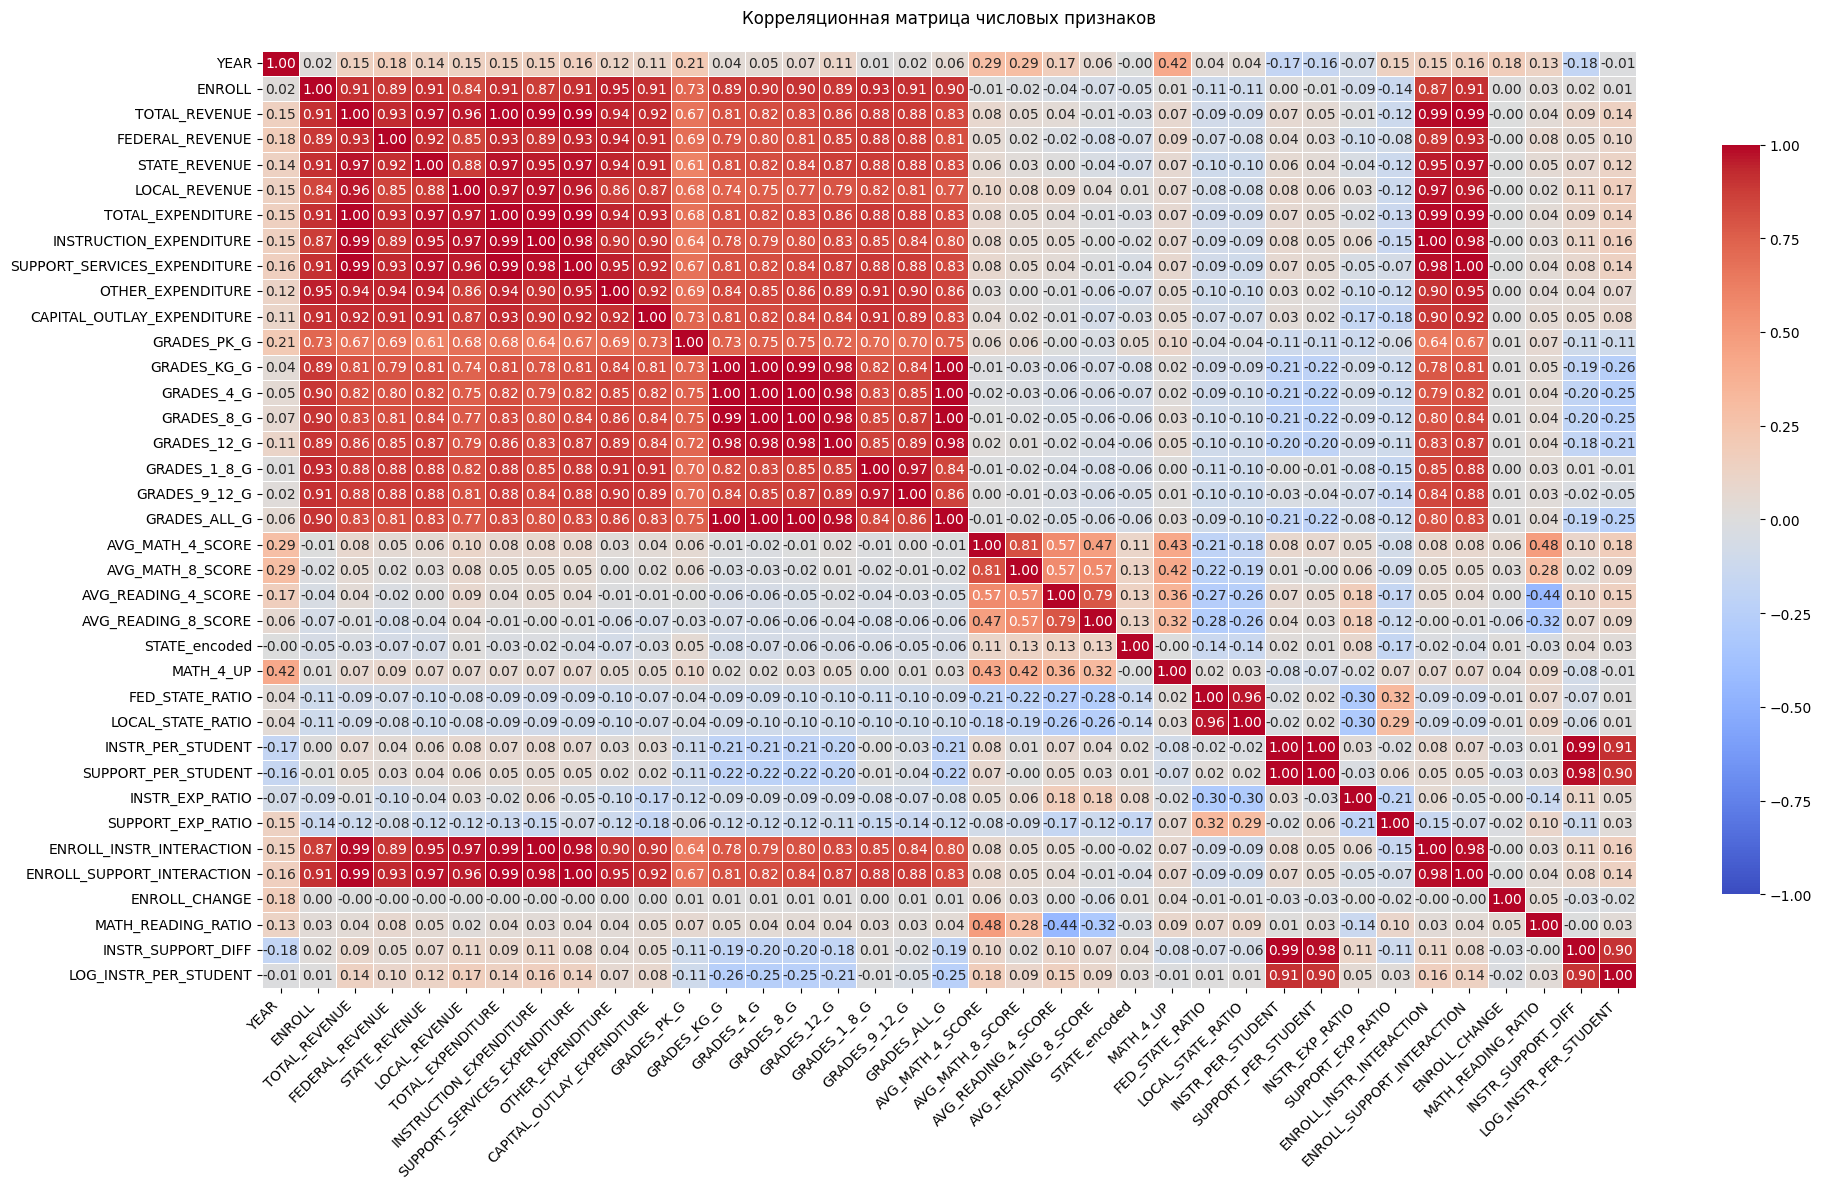

In [253]:
plt.figure(figsize=(20, 12))
numeric_data = data.select_dtypes(include=[np.number])
valid_cols = numeric_data.columns[numeric_data.notna().sum() > 5]
numeric_data = numeric_data[valid_cols]
corr_matrix = numeric_data.corr()

sns.heatmap(corr_matrix,annot=True, fmt=".2f", cmap='coolwarm',vmin=-1, vmax=1, center=0,linewidths=.5,cbar_kws={"shrink": .8})

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Корреляционная матрица числовых признаков', pad=20)
plt.tight_layout()
plt.show()

Разделение на признаки и целевую переменную

In [254]:
# Проверка пропущенных значений после создания признаков
print("NaN values before imputation:", data.isna().sum().sum())

# Заполнение пропусков медианными значениями
imputer = SimpleImputer(strategy='median')
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)

print("NaN values after imputation:", data_imputed.isna().sum().sum())
# Новые X и y
X = data.drop(columns=['MATH_4_UP'])
y = data['MATH_4_UP']

NaN values before imputation: 53
NaN values after imputation: 0


Разделение данных на обучающую и тестовую выборки

In [255]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

constant_columns = X_train.columns[X_train.nunique() == 1]
X_train = X_train.drop(columns=constant_columns)
X_test = X_test.drop(columns=constant_columns)

In [256]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled).replace([np.inf, -np.inf], np.nan)
X_test_scaled = pd.DataFrame(X_test_scaled).replace([np.inf, -np.inf], np.nan)

imputer = SimpleImputer(strategy='median')
X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled = imputer.transform(X_test_scaled)

## Логистическая регрессия

In [269]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'sag', 'saga']
}
grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring='f1_weighted')
grid_search.fit(X_train_scaled, y_train)
best_logreg = grid_search.best_estimator_
# Предсказания
lr_pred = best_logreg.predict(X_test_scaled)

C:\Users\Bizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Bizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Bizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Bizar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_sag.py:348: Conve

In [270]:
print("Logistic Regression:")
print(classification_report(y_test, lr_pred))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.82      0.96      0.88       233
           1       0.86      0.55      0.67       110

    accuracy                           0.83       343
   macro avg       0.84      0.75      0.77       343
weighted avg       0.83      0.83      0.81       343



## Случайный лес

In [271]:
# Обучение случайного леса
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='f1_weighted')
grid_search_rf.fit(X_train, y_train)
best_rf = grid_search_rf.best_estimator_

# Предсказания
rf_pred = best_rf.predict(X_test)


In [272]:
print("\nRandom Forest:")
print(classification_report(y_test, rf_pred))
print(f"Best parameters: {grid_search_rf.best_params_}")


Random Forest:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       233
           1       0.94      0.68      0.79       110

    accuracy                           0.88       343
   macro avg       0.90      0.83      0.85       343
weighted avg       0.89      0.88      0.88       343

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}


## Результаты

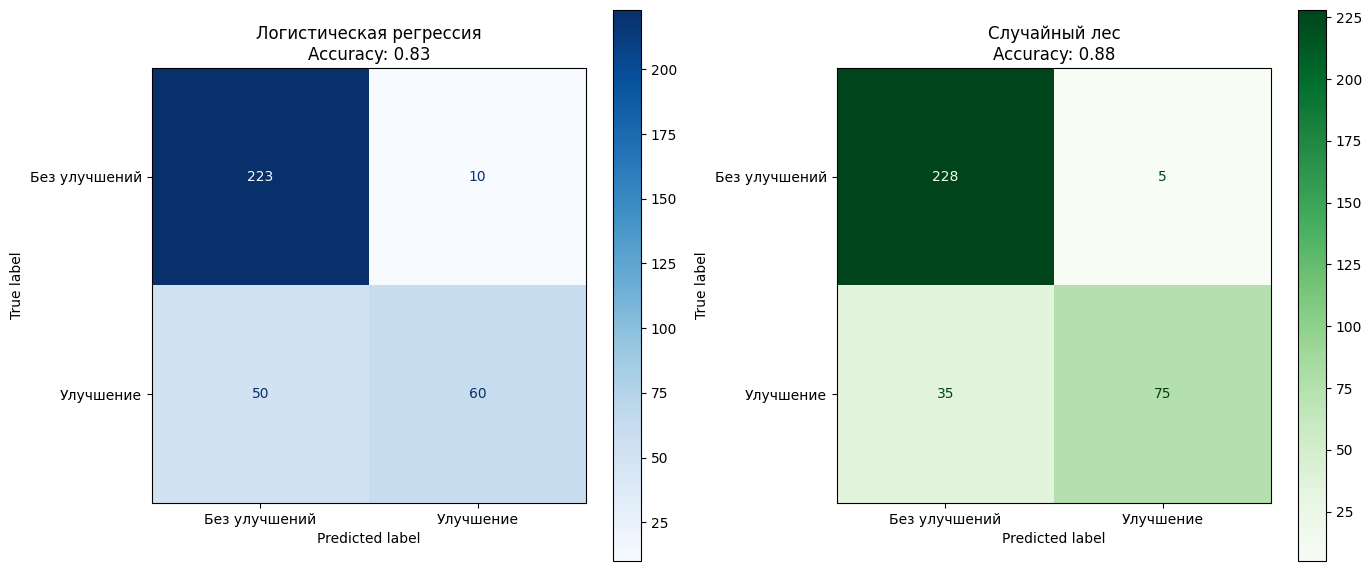

In [273]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


plt.figure(figsize=(14, 6))

# График для логистической регрессии
plt.subplot(1, 2, 1)
cm_lr = confusion_matrix(y_test, lr_pred)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, 
                               display_labels=['Без улучшений', 'Улучшение'])
disp_lr.plot(cmap='Blues', ax=plt.gca())
plt.title('Логистическая регрессия\nAccuracy: {:.2f}'.format(accuracy_score(y_test, lr_pred)))

# График для случайного леса
plt.subplot(1, 2, 2)
cm_rf = confusion_matrix(y_test, rf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                               display_labels=['Без улучшений', 'Улучшение'])
disp_rf.plot(cmap='Greens', ax=plt.gca())
plt.title('Случайный лес\nAccuracy: {:.2f}'.format(accuracy_score(y_test, rf_pred)))

plt.tight_layout()
plt.show()

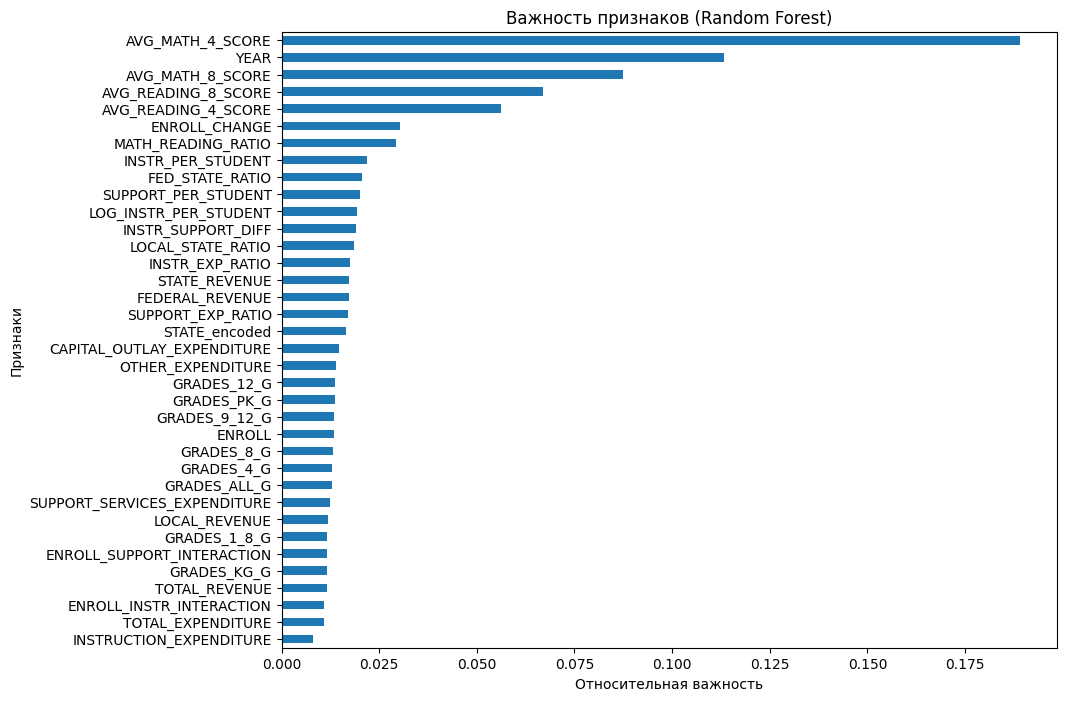

In [274]:
plt.figure(figsize=(10, 8))
feature_importances = pd.Series(best_rf.feature_importances_, index=X.columns)
feature_importances.sort_values().plot.barh()
plt.title('Важность признаков (Random Forest)')
plt.xlabel('Относительная важность')
plt.ylabel('Признаки')
plt.show()


In [275]:
# Топ-5 важных признаков по каждому методу
print("\nТоп-5 важных признаков Random Forest:")
print(feature_importances.sort_values(ascending=False).head(5))


Топ-5 важных признаков Random Forest:
AVG_MATH_4_SCORE       0.188964
YEAR                   0.113354
AVG_MATH_8_SCORE       0.087496
AVG_READING_8_SCORE    0.067005
AVG_READING_4_SCORE    0.056172
dtype: float64


## Выводы

1. Метрики качества

Для задачи бинарной классификации (рост/падение цен на недвижимость) использовались:

- F1-score (среднее гармоническое precision и recall) - оптимален при дисбалансе классов

- Precision (точность) - доля верно предсказанных случаев роста цен среди всех предсказанных ростов

- Recall (полнота) - доль верно найденных реальных случаев роста цен

- Accuracy (точность) - общая доля верных предсказаний

- ROC-AUC - способность модели разделять классы (рост/падение)

Обоснование выбора:

- F1-score учитывает и ложные роста (precision), и пропущенные роста (recall)

- ROC-AUC устойчив к дисбалансу классов

- Accuracy даёт общее представление о качестве

2. Сравнение моделей

Random Forest (F1=0.88) показал выдающиеся результаты:

- Precision=0.94 для класса "улучшение" 

- Recall=0.98 для класса "без улучшений" 

Logistic Regression (F1=0.83) - хороший уровень

Разница в 6% на F1 объясняется способностью Random Forest:

- Улавливать нелинейные взаимосвязи (например, пороговые эффекты)

- Учитывать взаимодействия признаков автоматически

3. Важность признаков

Топ-5 значимых факторов (Random Forest):

- AVG_MATH_4_SCORE  (0.189) - Средний балл по математике в 4 классе (ключевой индикатор)

- Year (0.113) - год обучения 

- AVG_MATH_8_SCORE (0.087) - Успеваемость по математике в 8 классе.

- AVG_READING_8_SCORE (0.067) - Баллы по чтению в 8 классе.

- AVG_READING_4_SCORE (0.056) - Чтение в 4 классе.